In [1]:
%reload_ext autoreload
%autoreload 2
%matplotlib inline

In [2]:
import torch
from nanodrz.model import DiarizeGPT, Config
from nanodrz.data import libritts_test, artificial_diarisation_sample
from nanodrz.utils import visualise_annotation, play

In [3]:
speakers = libritts_test()
ckpt = torch.load("/home/harry/0004600.pt")
config = Config(**ckpt["config"])
model:DiarizeGPT = DiarizeGPT.from_pretrained(ckpt).cuda()

/home/harry/diarisation/.venv/lib/python3.10/site-packages/torch/nn/utils/weight_norm.py:30: UserWarning: torch.nn.utils.weight_norm is deprecated in favor of torch.nn.utils.parametrizations.weight_norm.
  warnings.warn("torch.nn.utils.weight_norm is deprecated in favor of torch.nn.utils.parametrizations.weight_norm.")


28.1616875


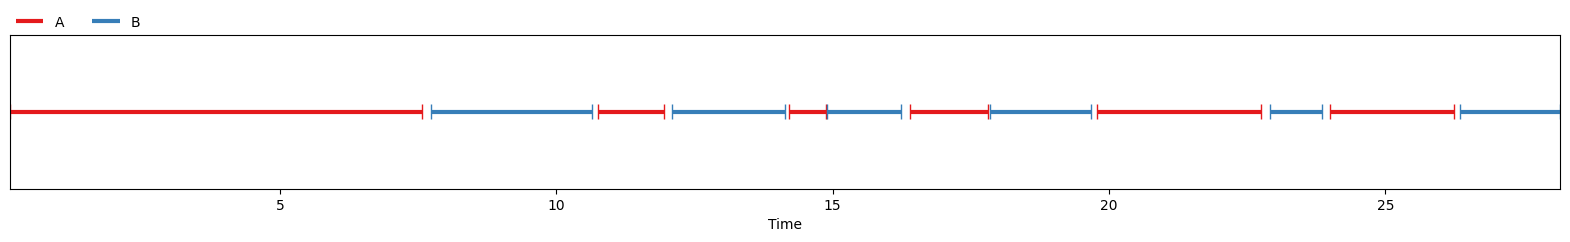

[[0.117625, 7.4540625, 'A'],
 [7.7325, 2.9215625, 'B'],
 [10.754312500000001, 1.2005625, 'A'],
 [12.104125, 2.0361875, 'B'],
 [14.215250000000001, 0.6706875, 'A'],
 [14.90075, 1.3315, 'B'],
 [16.396375, 1.4190625, 'A'],
 [17.84075, 1.8368125, 'B'],
 [19.7891875, 2.96125, 'A'],
 [22.919875, 0.9349375, 'B'],
 [24.005625000000002, 2.2383125, 'A'],
 [26.347250000000003, 1.8144375, 'B']]

In [4]:
# Use the same parameters that the model was trained on to generate a sample
audio, labels = artificial_diarisation_sample(speakers, **config.data.model_dump())
print(audio.shape[-1]/16000)
visualise_annotation(labels)
play(audio)
labels

In [5]:
def convert_tokens_to_labels(tokens):
    nlabels = [] 

    for (start, end, label) in tokens.split(3):
        start= start*model.config.data.max_secs / model.num_time_tokens
        end = end*model.config.data.max_secs / model.num_time_tokens
        label = chr(ord('A') + (model.num_embs-(label+1)).item())
        nlabels.append([start.item(), end.item(), label])

    return nlabels

In [6]:
tokens = model.generate(audio.cuda())
print(tokens)


/home/harry/diarisation/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


tensor([142, 181, 511,   4,  57, 511,  66, 108, 510, 233, 307, 510, 356, 394,
        511, 380, 399, 510, 189, 246, 510, 327, 348, 511, 110, 139, 511, 389,
        442, 511], device='cuda:0')


/home/harry/diarisation/src/nanodrz/model.py:265: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  return torch.tensor(tokens)


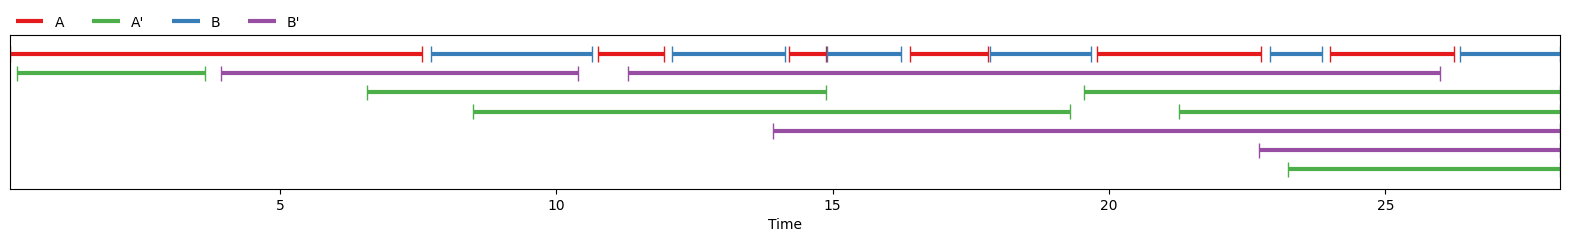

In [7]:
assert tokens.shape[-1] % 3 == 0
nlabels = convert_tokens_to_labels(tokens)
for l in nlabels:
    l[2] = l[2]+ "'"
visualise_annotation(labels+nlabels)